# Objetivo del EDA

### El análisis exploratorio tiene como finalidad comprender la distribución de las variables, detectar valores atípicos, identificar relaciones entre variables y descubrir patrones que puedan explicar el comportamiento de la variable objetivo (review_score).

### Además, este análisis permitirá validar hipótesis de negocio y orientar la selección de variables para el posterior entrenamiento del modelo de Machine Learning.

# Preguntas de negocio

### Durante el EDA intentaremos responder preguntas como:

### ¿Los retrasos afectan la satisfacción? 

### ¿Los clientes frecuentes califican mejor?

### ¿Los vendedores con mejor historial reciben mejores reviews?

### ¿Existe estacionalidad en las compras?

### ¿El valor de la compra influye en la calificación?

### ¿Qué características distinguen una compra con review 5 de una review 1?


# Hipótesis Testing
### H1 — Los retrasos afectan la satisfacción del cliente

Pregunta de negocio:
¿Los pedidos retrasados reciben peores calificaciones?

### H₀: No existe una diferencia significativa en la calificación promedio entre pedidos entregados a tiempo y pedidos retrasados.
### H₁: Los pedidos retrasados presentan una calificación promedio significativamente menor que los pedidos entregados a tiempo.

Variables principales:

is_delayed
delivery_delay_days
delivery_time_days
review_score

Qué buscar:

Diferencia de medias/medianas.
Distribución de review_score según is_delayed.
Correlación entre tiempo/retraso y calificación.

Resultado esperado según el EDA actual:
La evidencia preliminar apoya H₁, ya que is_delayed y delivery_time_days presentan las correlaciones negativas más fuertes con review_score.

### H2 — Los clientes frecuentes califican mejor

Pregunta de negocio:
¿Los clientes con mayor experiencia de compra tienden a otorgar mejores calificaciones?

### H₀: No existe una diferencia significativa en la calificación entre clientes frecuentes y clientes nuevos/menos frecuentes.
### H₁: Los clientes frecuentes presentan una calificación promedio significativamente mayor.

Variables principales:

customer_total_orders
is_new_customer
customer_days_since_first_purchase
review_score

Qué buscar:

Comparación de review_score entre clientes nuevos y recurrentes.
Relación entre cantidad de pedidos y calificación.
Distribución de reviews según segmentos de frecuencia.

Resultado preliminar:
La correlación observada es muy baja, por lo que no existe evidencia fuerte a favor de H₁ a partir de este análisis univariado.

### H3 — Los vendedores con mejor historial reciben mejores reviews

Pregunta de negocio:
¿La reputación histórica de un vendedor está relacionada con la satisfacción de sus clientes?

### H₀: No existe relación significativa entre el historial de calificaciones del vendedor y la calificación del pedido actual.
### H₁: Los vendedores con mejor historial de calificaciones tienden a recibir mejores reviews en sus pedidos actuales.

Variables principales:

seller_avg_review
seller_total_orders
seller_total_sales
review_score

Qué buscar:

Correlación entre seller_avg_review y review_score.
Comparación de reviews entre vendedores con distinta reputación.
Relación entre volumen de ventas y satisfacción.

Resultado preliminar:
Existe evidencia inicial a favor de H₁, ya que seller_avg_review presenta una correlación positiva considerable (~0.27).

### H4 — Existe estacionalidad en el comportamiento de compra

Pregunta de negocio:
¿El volumen de compras varía según el período del año, mes, día u hora?

### H₀: El volumen de compras se distribuye de manera homogénea a lo largo del tiempo.
### H₁: El volumen de compras presenta patrones temporales o estacionales significativos.

Variables principales:

purchase_month
purchase_quarter
purchase_week_day
purchase_hour
Cantidad de pedidos

Qué buscar:

Volumen de pedidos por mes.
Volumen por trimestre.
Compras por día de la semana.
Compras por hora.

Importante: esta hipótesis analiza principalmente el comportamiento de compra, no necesariamente la satisfacción.

Si querés mantener el foco 100% en review_score, podés agregar una segunda hipótesis:

H₁: La calificación promedio (review_score) presenta diferencias significativas según el período de compra.

### H5 — El valor de la compra influye en la satisfacción

Pregunta de negocio:
¿Los clientes que realizan compras de mayor valor tienden a otorgar diferentes calificaciones?

### H₀: No existe una relación significativa entre el valor de la compra y review_score.
### H₁: Existe una relación significativa entre el valor de la compra y review_score.

Variables principales:

total_order_value
customer_avg_ticket
customer_total_spent
review_score

Qué buscar:

Correlación.
Diferencia de ticket promedio entre reviews.
Distribución del valor del pedido para reviews 1 y 5.
Posibles efectos no lineales.

Resultado preliminar:
Las correlaciones observadas son relativamente bajas, por lo que la evidencia inicial no muestra una relación fuerte entre valor de compra y satisfacción.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

# Configuración de estilo global para Seaborn y Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [5]:
model_df = pd.read_csv ('Data_ML_EDA.csv')

In [6]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    model_df[col] = pd.to_datetime(model_df[col])

In [7]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   order_id                            99441 non-null  object        
 1   customer_id                         99441 non-null  object        
 2   order_status                        99441 non-null  object        
 3   order_purchase_timestamp            99441 non-null  datetime64[ns]
 4   order_approved_at                   99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date        97658 non-null  datetime64[ns]
 6   order_delivered_customer_date       96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date       99441 non-null  datetime64[ns]
 8   fase_pedido                         99441 non-null  object        
 9   customer_unique_id                  99441 non-null  object        
 10  delivery_time_days    

# Distribucion de calificaciones

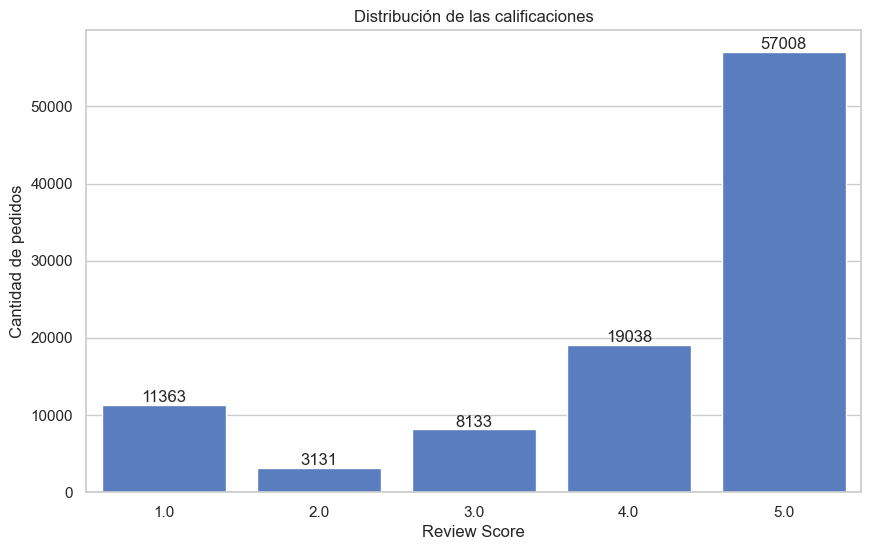

In [8]:
plt.figure()

ax = sns.countplot(
    data=model_df,
    x="review_score",
    order=sorted(model_df["review_score"].dropna().unique())
)

plt.title("Distribución de las calificaciones")
plt.xlabel("Review Score")
plt.ylabel("Cantidad de pedidos")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Distribucion porcentual de cada calificación
## Se busca saber que porcentaje del dataset conlleva cada calificacion

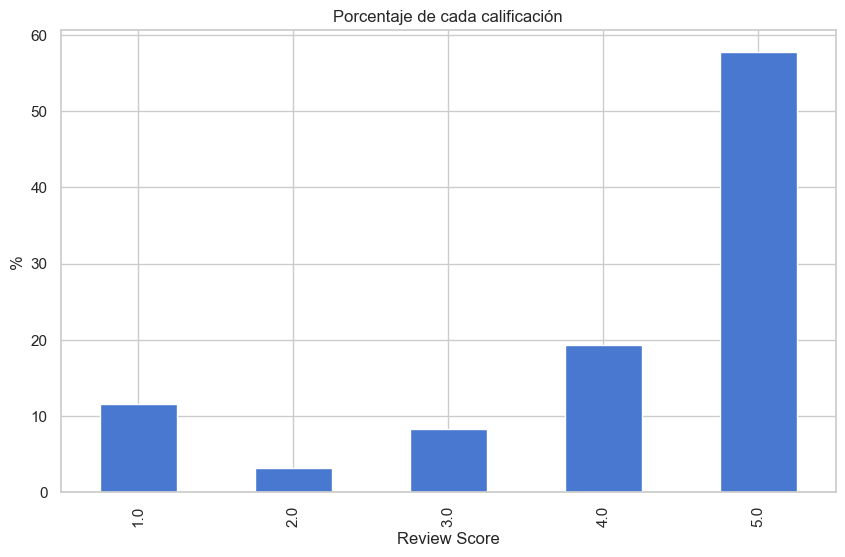

In [9]:
(
    model_df["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Porcentaje de cada calificación")
plt.ylabel("%")
plt.xlabel("Review Score")

plt.show()

# Distribucion del valor de compra
## Se busca entender el valor de compra promedio y la distribucion del resto de valores

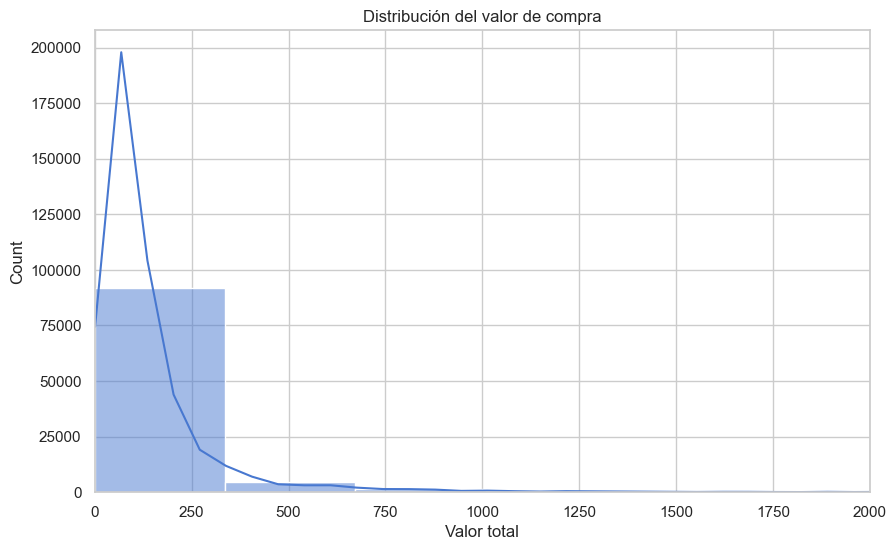

In [10]:
sns.histplot(
    model_df["total_order_value"],
    bins=40,
    kde=True
)

plt.title("Distribución del valor de compra")
plt.xlabel("Valor total")
plt.xlim(0, 2000)

plt.show()

# Distribucion del tiempo de entrega
## Se busca mostrar cual es el tiempo de entrega promedio y el resto de valores

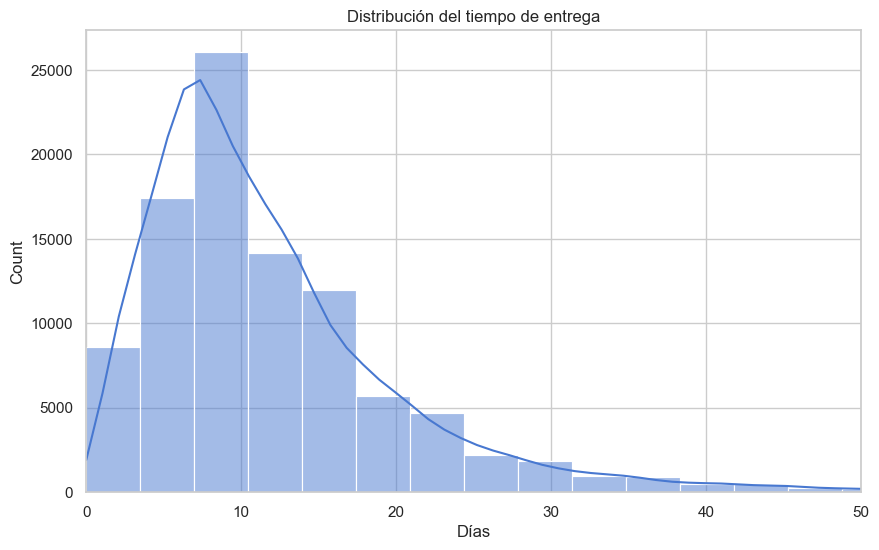

In [11]:
sns.histplot(
    model_df["delivery_time_days"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribución del tiempo de entrega")
plt.xlabel("Días")
plt.xlim(0, 50)

plt.show()

# Distribucion de retrasos en las entregas
## Se muestran valores negativos (llegan antes de la fecha estipulada) y positivos (Despues de la fecha estipulada)

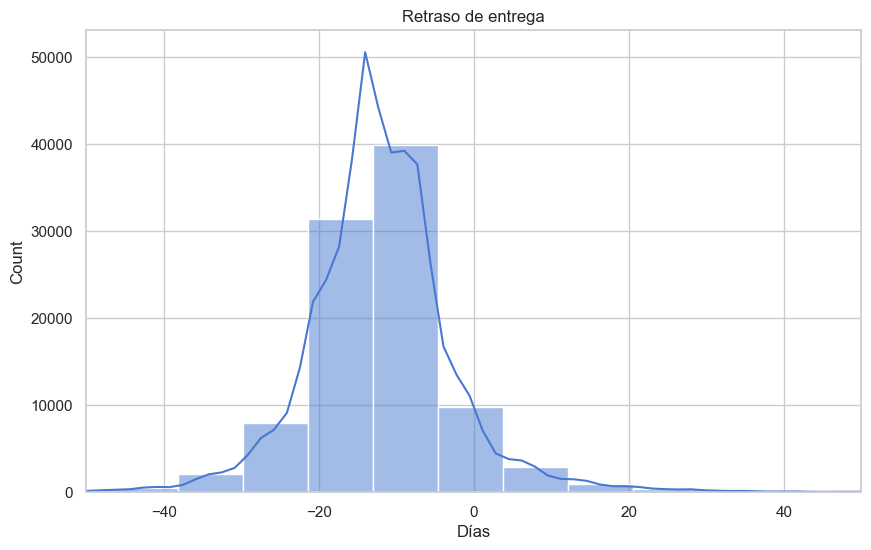

In [12]:
sns.histplot(
    model_df["delivery_delay_days"].dropna(),
    bins=40,
    kde=True
)

plt.title("Retraso de entrega")
plt.xlabel("Días")
plt.xlim(-50, 50)

plt.show()

# Ratio del envio en el valor
## se muestra que porcentaje del valor total del pedido corresponde al envio

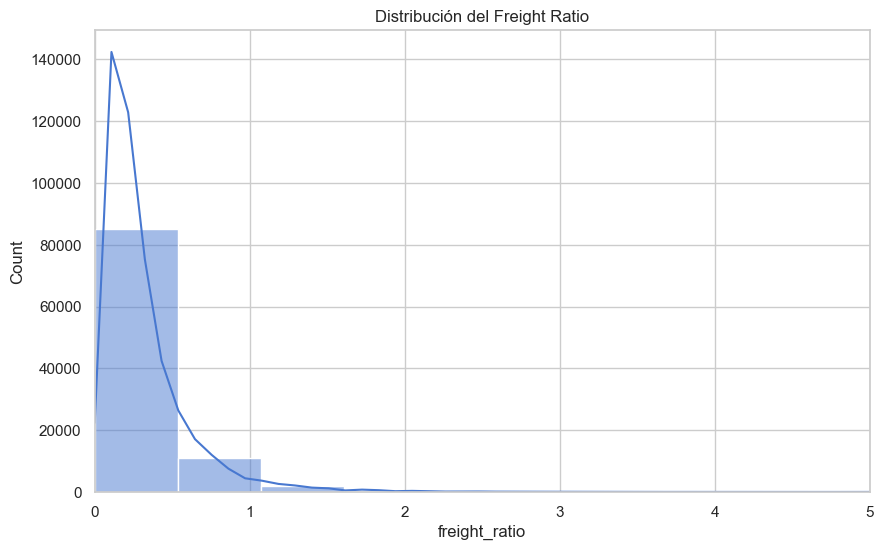

In [13]:
sns.histplot(
    model_df["freight_ratio"],
    bins=40,
    kde=True
)

plt.title("Distribución del Freight Ratio")
plt.xlim(0, 5)
plt.show()

# Gasto total por cliente
## Se muestra cuanto gasta cada cliente registrado en total.

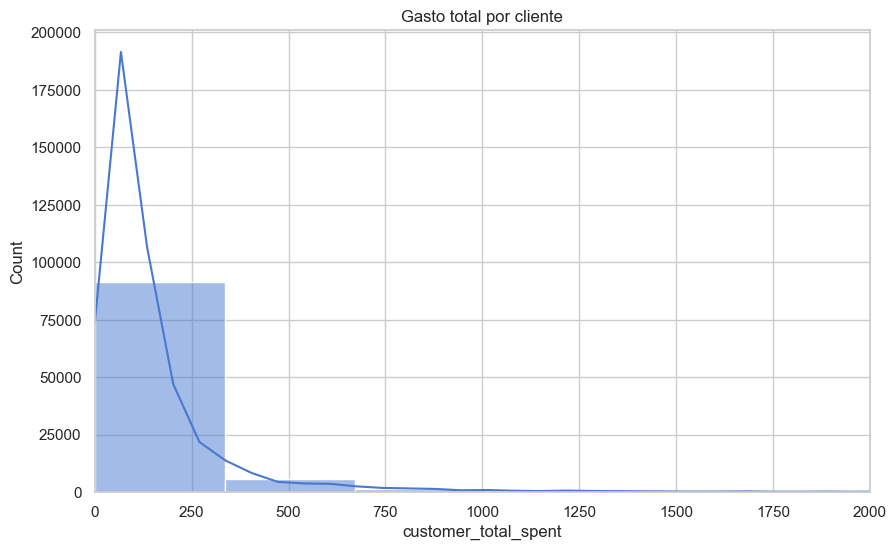

In [14]:
sns.histplot(
    model_df["customer_total_spent"],
    bins=40,
    kde=True
)

plt.title("Gasto total por cliente")
plt.xlim(0, 2000)
plt.show()

# Ticket promedio del cliente
## Se muestra cuanto gastan los clientes en promedio por pedido

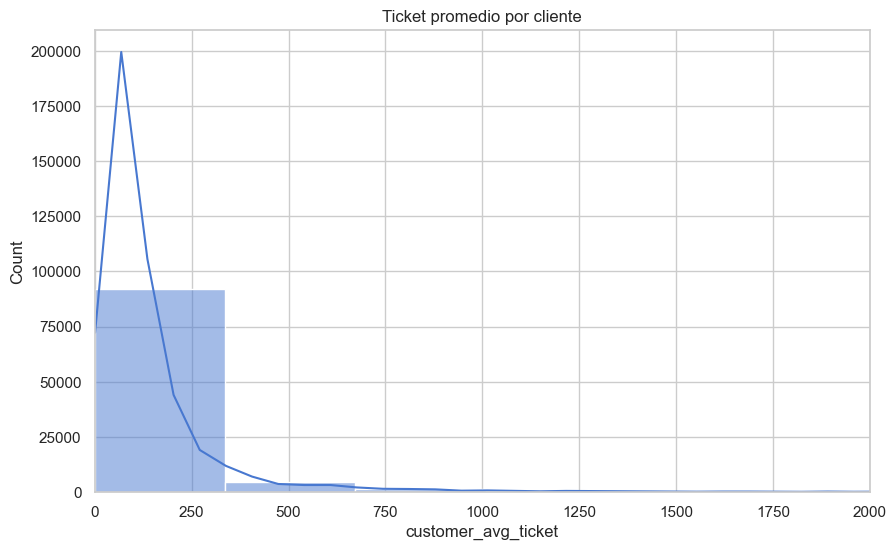

In [15]:
sns.histplot(
    model_df["customer_avg_ticket"],
    bins=40,
    kde=True
)

plt.title("Ticket promedio por cliente")
plt.xlim(0, 2000)
plt.show()

# Volumen de producto
## Muestra el tamaño de los productos que ordenan los clientes

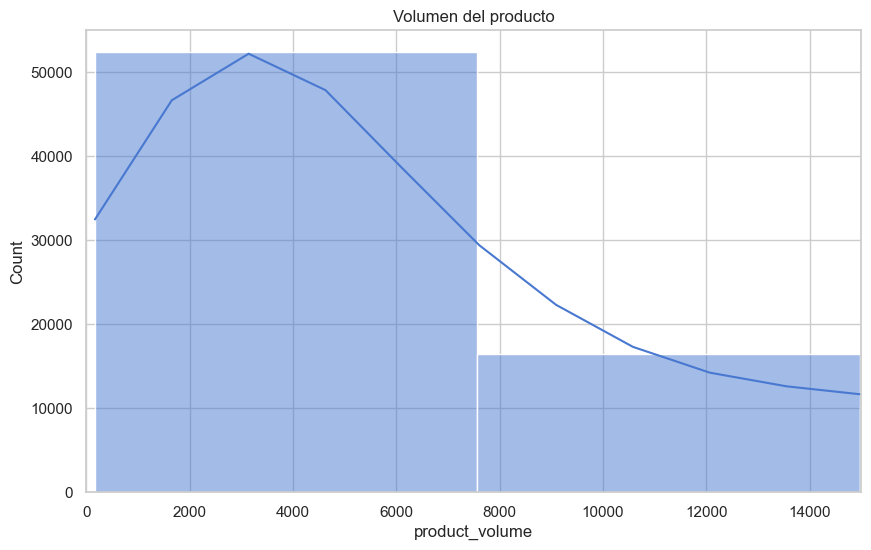

In [16]:
sns.histplot(
    model_df["product_volume"].dropna(),
    bins=40,
    kde=True
)

plt.title("Volumen del producto")
plt.xlim(0, 15000)
plt.show()

# Ventas por vendedor
## Muestra cuantas ventas llegan a lograr los distintos vendedores registrados

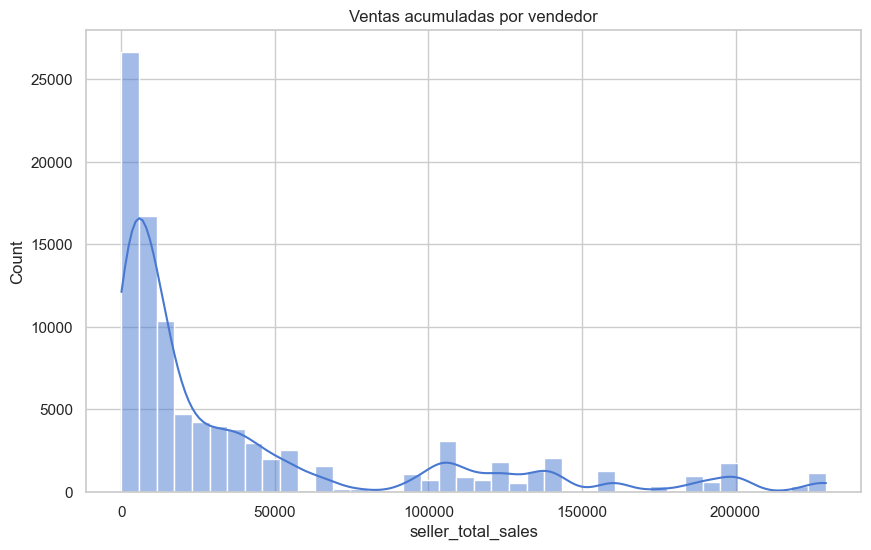

In [17]:
sns.histplot(
    model_df["seller_total_sales"],
    bins=40,
    kde=True
)

plt.title("Ventas acumuladas por vendedor")

plt.show()

# Estado de los pedidos
## Muestra el estado de los pedidos del dataset en el momento donde este se descargó

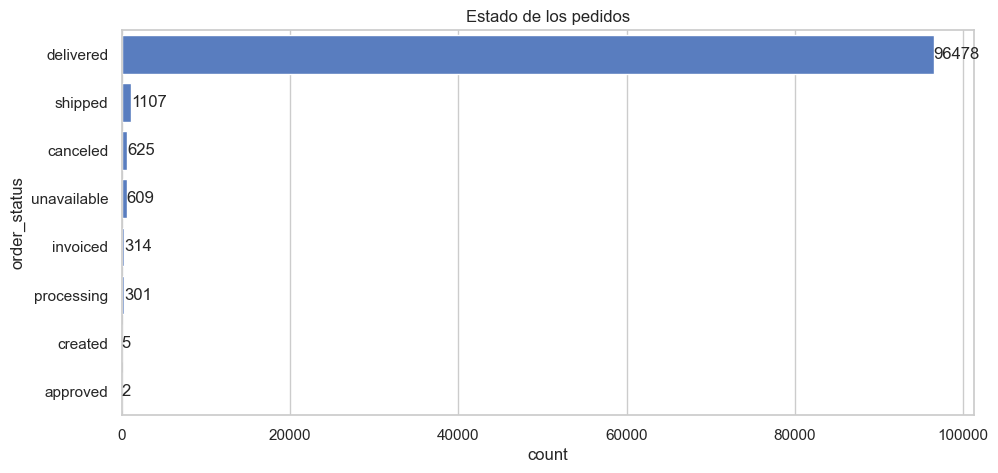

In [18]:
plt.figure(figsize=(11,5))

ax = sns.countplot(
    data=model_df,
    y="order_status",
    order=model_df["order_status"].value_counts().index
)

plt.title("Estado de los pedidos")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Compras por mes
## Muestra el comportamiento en cantidad de compras de los clientes segun el mes.

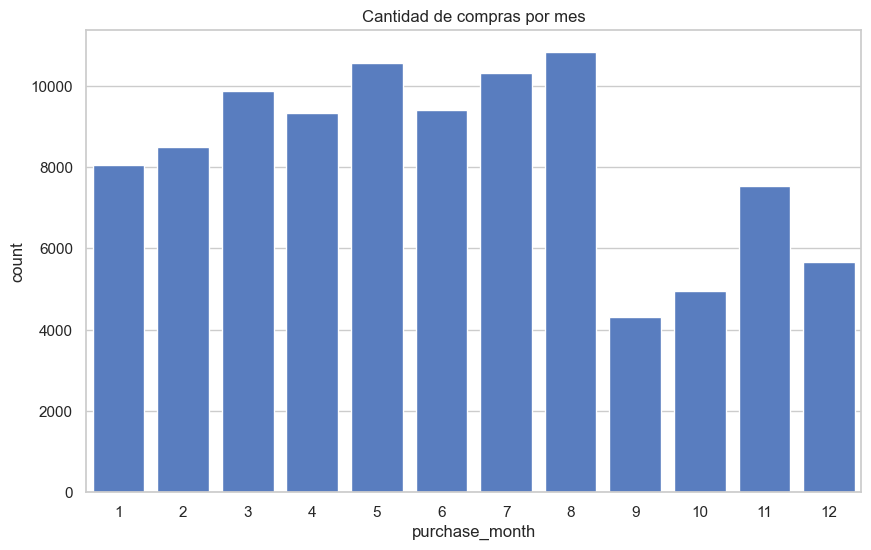

In [19]:
sns.countplot(
    data=model_df,
    x="purchase_month"
)

plt.title("Cantidad de compras por mes")

plt.show()

# Compra por según dia de la semana
## Muestra las compras totales en los distintos dias de la semana

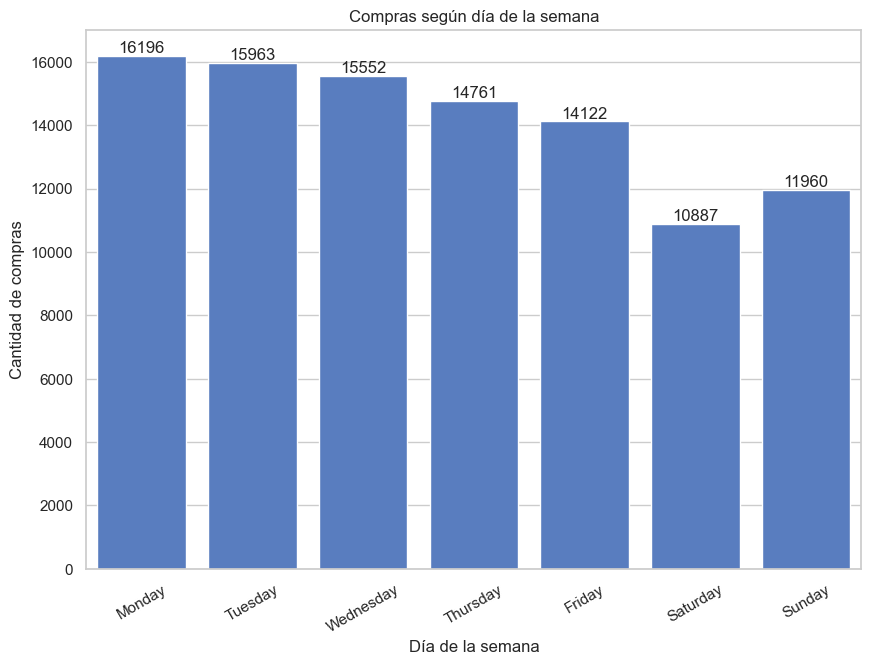

In [20]:
dias = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

model_df["purchase_week_day_name"] = model_df["purchase_week_day"].map(dias) 

orden = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(10,7))

ax = sns.countplot(
    data=model_df,
    x="purchase_week_day_name",
    order=orden
)

plt.xticks(rotation=30)

plt.title("Compras según día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de compras")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Cantidad de pagos por pedido
## Muestra en cuantos pagos realizan la compra los clientes

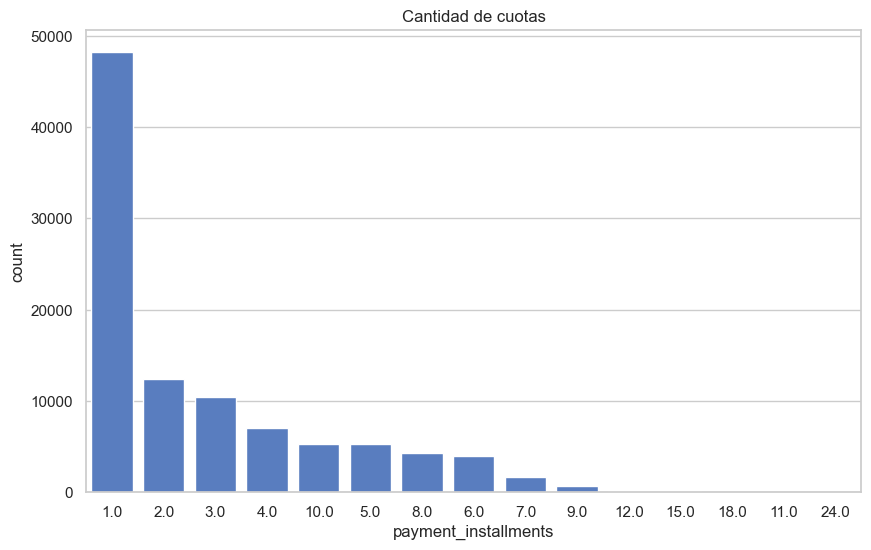

In [21]:
top = model_df["payment_installments"].value_counts().head(15).index

sns.countplot(
    data=model_df,
    x="payment_installments",
    order=top
)

plt.title("Cantidad de cuotas")

plt.show()

# Calificacion segun dias de atraso
## Muestra la relacion de la calificacion con los dias de retraso de la entrega

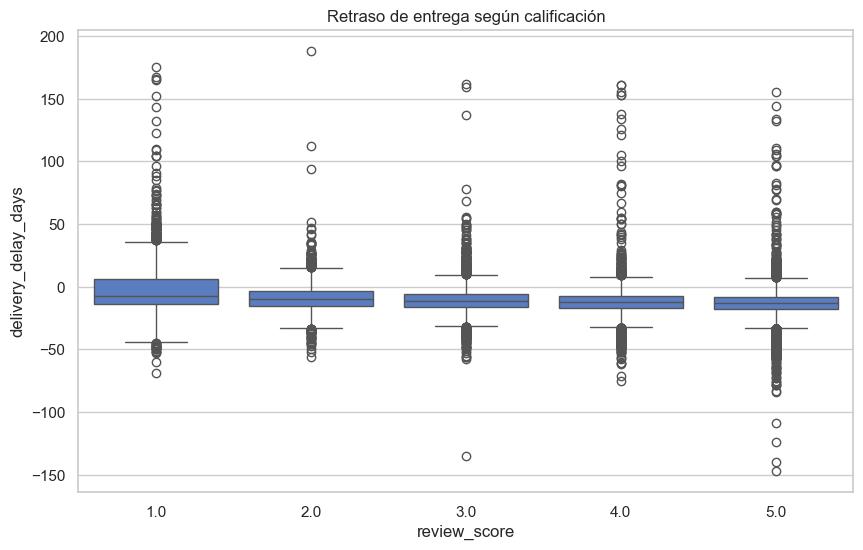

In [22]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="delivery_delay_days"
)

plt.title("Retraso de entrega según calificación")

plt.show()

# Dias de entrega segun la review
## Muestra la relacion de los dias de entrega desde la aprobacion del pedido y la puntuacion en la review

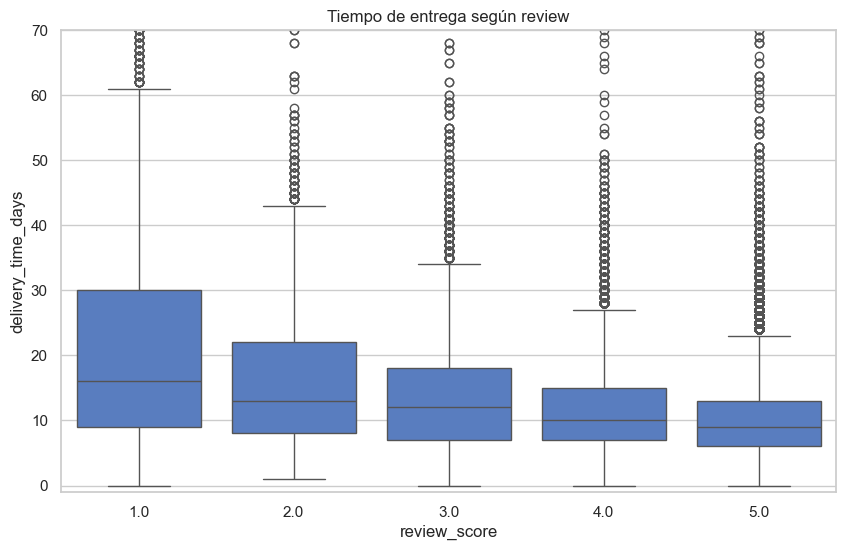

In [23]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="delivery_time_days"
)

plt.title("Tiempo de entrega según review")
plt.ylim(-1, 70)
plt.show()

## Valor de compra segun review
### Muestra el valor de la compra y la puntuación en la review

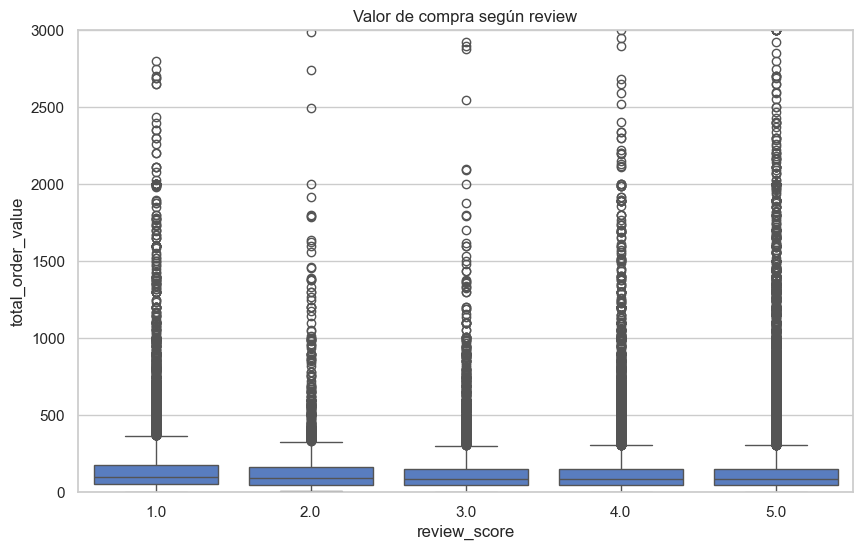

In [24]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="total_order_value"
)

plt.title("Valor de compra según review")
plt.ylim(0, 3000)
plt.show()

## Porcentaje del envio en el valor final de la orden y su review
### Muestra como puntuan segun el valor del envio en el valor final

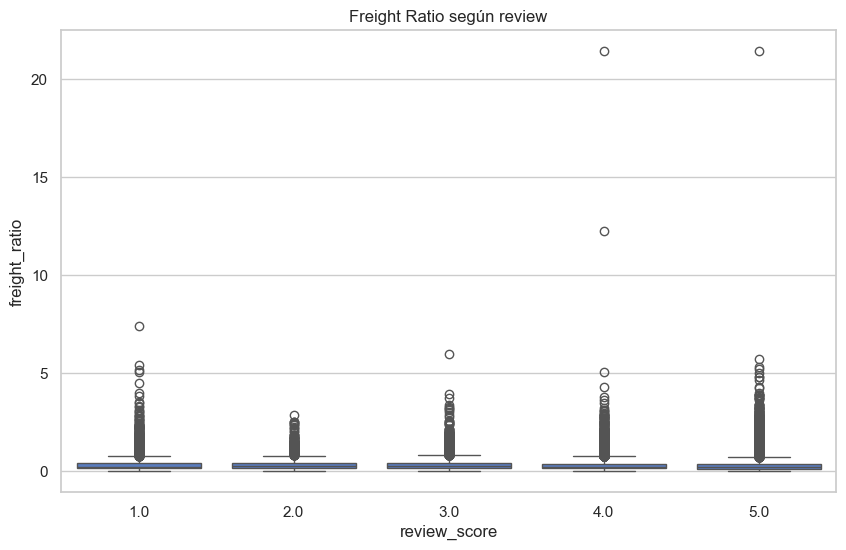

In [25]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="freight_ratio"
)

plt.title("Freight Ratio según review")

plt.show()

## Cantidad de compras efectuadas por el cliente y sus reviews
### Muestra como actuan los clientes en las reviews segun sus compras efectuadas

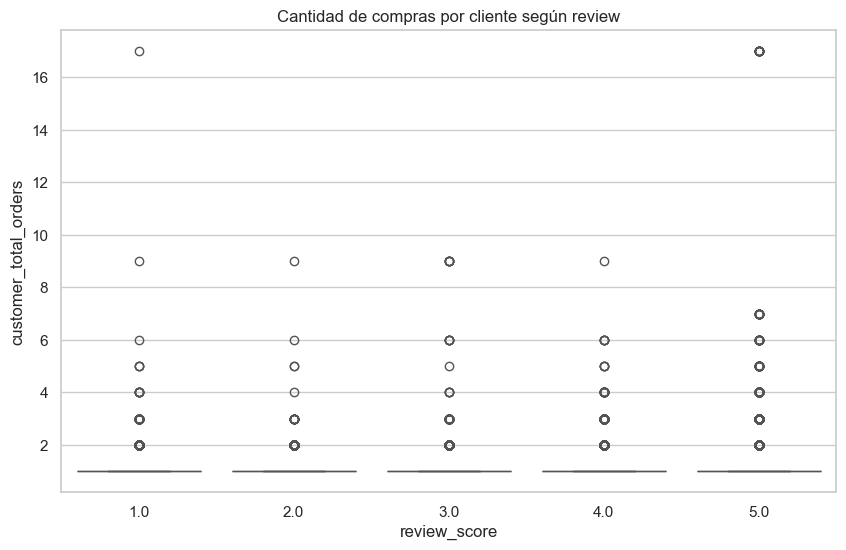

In [26]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="customer_total_orders"
)

plt.title("Cantidad de compras por cliente según review")

plt.show()

## Promedio historico del vendedor
### Muestra como se comportan las reviews en los vendedores dentro y fuera del su promedio de review

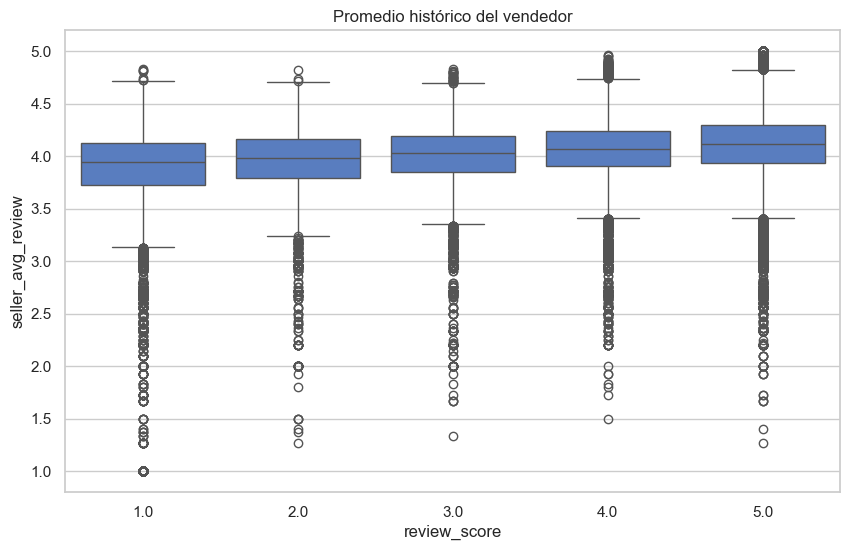

In [27]:
sns.boxplot(
    data=model_df,
    x="review_score",
    y="seller_avg_review"
)

plt.title("Promedio histórico del vendedor")

plt.show()

## Matriz de correlacion
### Muestra como se comportan las variables entre si, es decir, que variables se mueven en conjunto y cuales tienen comportamientos contrarios

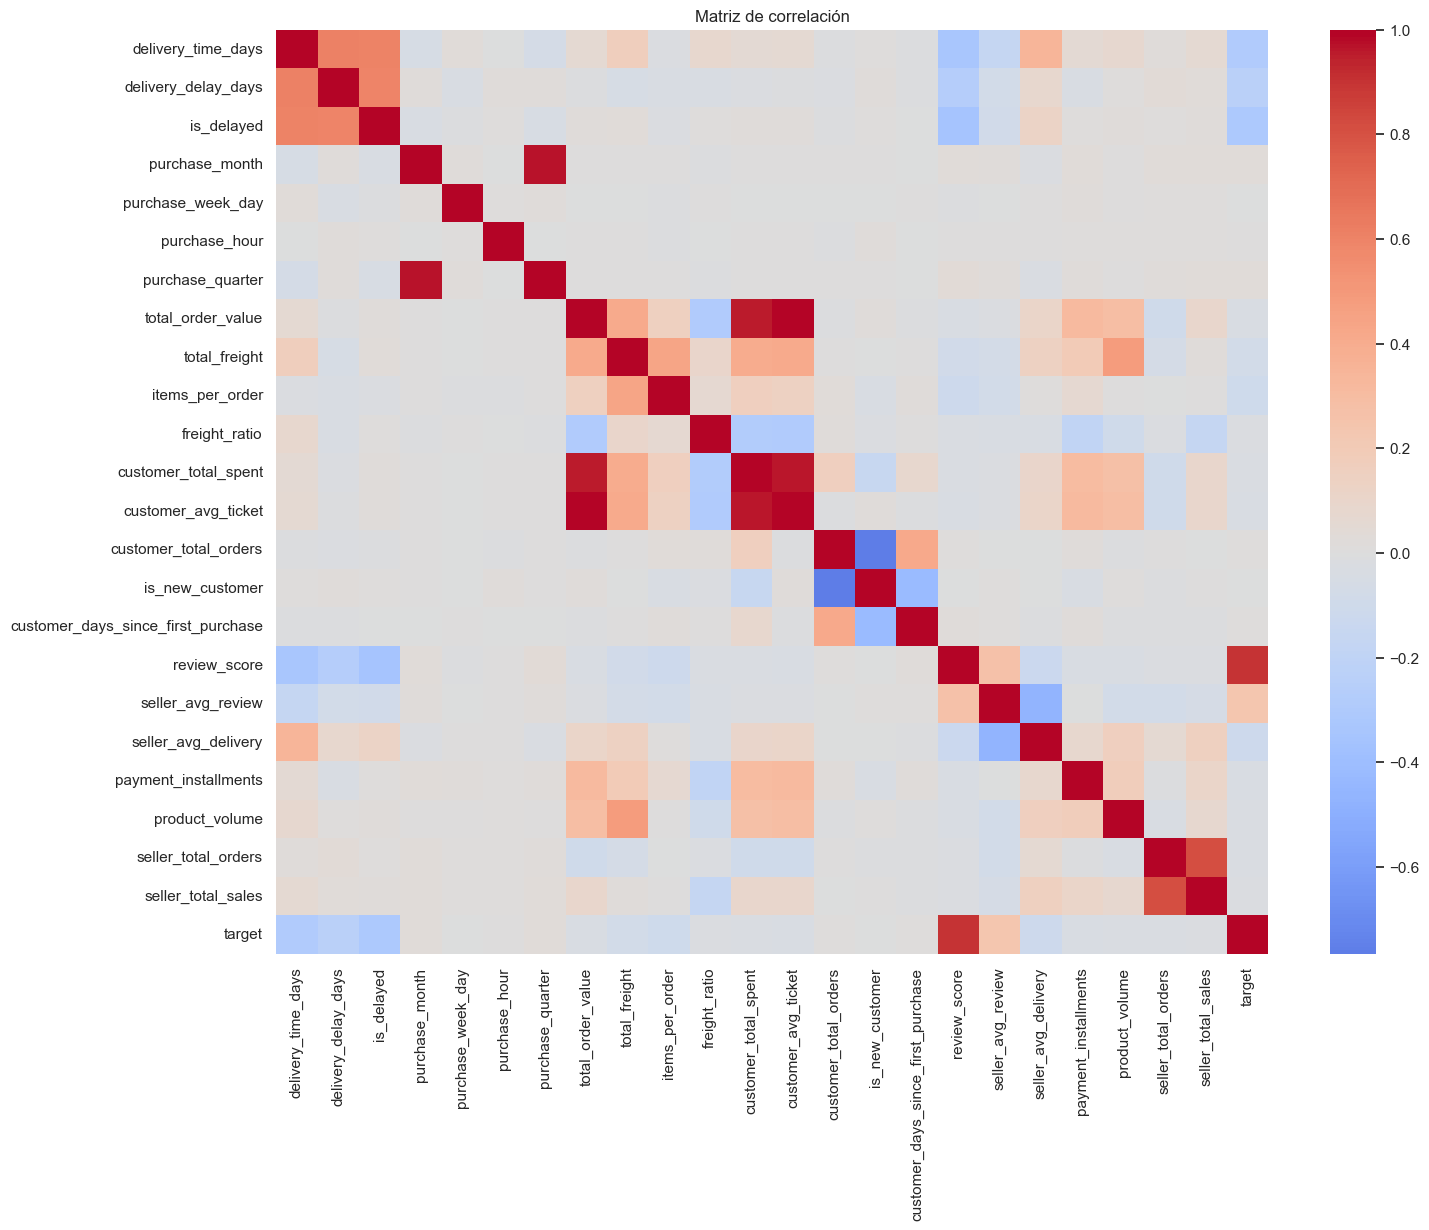

In [28]:
numeric_df = model_df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()

##  Correlacion de las variables con la calificacion
### Muestra como se comportan las variables en conjunto con review_score

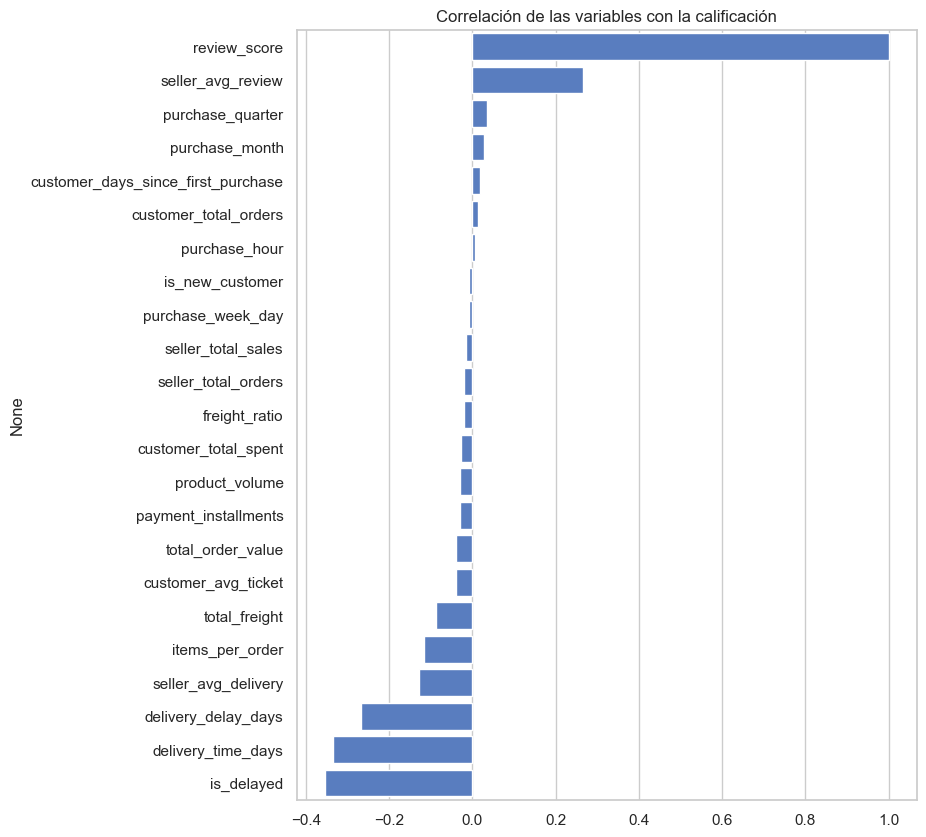

In [47]:
corr_review = (
    numeric_df
    .corr()["review_score"]
    .drop(["target"])
    .sort_values(ascending=False)
    )

plt.figure(figsize=(8,10))

sns.barplot(
    x=corr_review.values,
    y=corr_review.index
)

plt.title("Correlación de las variables con la calificación")

plt.show()

## Muestra estacionalidad de las calificaciones

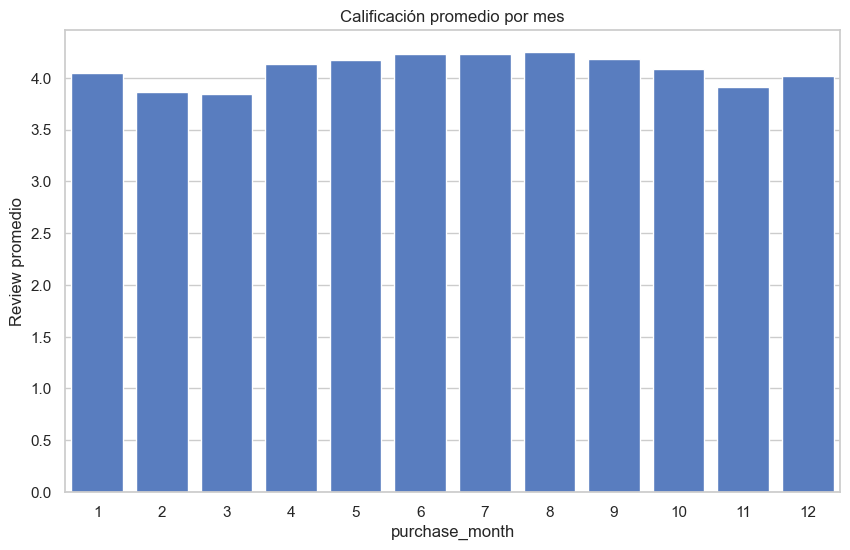

In [30]:
sns.barplot(
    data=model_df,
    x="purchase_month",
    y="review_score",
    estimator="mean",
    errorbar=None
)

plt.title("Calificación promedio por mes")

plt.ylabel("Review promedio")

plt.show()

# Analisis Estadísticos descriptivos

In [31]:
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,96476.0,12.094086,9.551746,0.00,6.000000,10.000000,15.000000,209.000000
delivery_delay_days,96476.0,-11.876881,10.183854,-147.00,-17.000000,-12.000000,-7.000000,188.000000
is_delayed,99441.0,0.065717,0.247789,0.00,0.000000,0.000000,0.000000,1.000000
purchase_month,99441.0,6.032220,3.232999,1.00,3.000000,6.000000,8.000000,12.000000
purchase_week_day,99441.0,2.755735,1.966495,0.00,1.000000,3.000000,4.000000,6.000000
purchase_hour,99441.0,14.770829,5.326800,0.00,11.000000,15.000000,19.000000,23.000000
purchase_quarter,99441.0,2.355487,1.061644,1.00,1.000000,2.000000,3.000000,4.000000
total_order_value,98666.0,137.754076,210.645145,0.85,45.900000,86.900000,149.900000,13440.000000
total_freight,98666.0,22.823562,21.650909,0.00,13.850000,17.170000,24.040000,1794.960000
items_per_order,98666.0,1.141731,0.538452,1.00,1.000000,1.000000,1.000000,21.000000


In [32]:
numeric_df.agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    'skew',
    'kurt'
]).T

,mean,median,std,min,max,skew,kurt
delivery_time_days,12.094086,10.000000,9.551746,0.00,209.000000,3.828790,39.261952
delivery_delay_days,-11.876881,-12.000000,10.183854,-147.00,188.000000,2.014360,28.051494
is_delayed,0.065717,0.000000,0.247789,0.00,1.000000,3.505337,10.287597
purchase_month,6.032220,6.000000,3.232999,1.00,12.000000,0.206302,-0.978835
purchase_week_day,2.755735,3.000000,1.966495,0.00,6.000000,0.167725,-1.166975
purchase_hour,14.770829,15.000000,5.326800,0.00,23.000000,-0.601849,0.182002
purchase_quarter,2.355487,2.000000,1.061644,1.00,4.000000,0.171606,-1.201662
total_order_value,137.754076,86.900000,210.645145,0.85,13440.000000,9.727741,266.066939
total_freight,22.823562,17.170000,21.650909,0.00,1794.960000,12.052723,565.341732
items_per_order,1.141731,1.000000,0.538452,1.00,21.000000,7.527006,114.850341


In [33]:
from scipy.stats import normaltest

variables = [
    "delivery_time_days",
    "delivery_delay_days",
    "total_order_value",
    "freight_ratio"
]

for var in variables:
    data = numeric_df[var].dropna()

    stat, p = normaltest(data)

    print(f"{var}")
    print(f"Statistic: {stat:.2f}")
    print(f"p-value: {p:.5f}")

    if p < 0.05:
        print("No sigue una distribución normal\n")
    else:
        print("Distribución aproximadamente normal\n")

delivery_time_days
Statistic: 84005.41
p-value: 0.00000
No sigue una distribución normal

delivery_delay_days
Statistic: 55299.70
p-value: 0.00000
No sigue una distribución normal

total_order_value
Statistic: 155637.85
p-value: 0.00000
No sigue una distribución normal

freight_ratio
Statistic: 160092.13
p-value: 0.00000
No sigue una distribución normal



# Hallazgos y problemas de negocio:

## ¿Qué factores influyen en la satisfacción de los clientes de un e-commerce?

↓

## Hallazgo 1

### 🚚 La logística aparece como el principal factor asociado a la satisfacción.

↓

## Hallazgo 2

### ⏱️ Los retrasos y mayores tiempos de entrega están asociados con peores reviews.

↓

## Hallazgo 3

### ⭐ El desempeño histórico del vendedor también está relacionado con la satisfacción, aunque debemos controlar posibles problemas de leakage.

↓

## Hallazgo 4

### 📅💰👤 Variables demográficas/comerciales como fecha de compra, gasto y antigüedad del cliente parecen tener mucha menor relación.

↓

## Pregunta de ML:

## ¿Podemos predecir qué clientes están en riesgo de dejar una mala valoración utilizando la información disponible al momento de la compra?

| ID     | Hipótesis                                                          | Variable objetivo    | Resultado preliminar |
| ------ | ------------------------------------------------------------------ | ------------------   | -------------------- |
| **H1** | Los retrasos afectan negativamente la satisfacción                 | `review_score`       | 🟢 Evidencia a favor |
| **H2** | Los clientes frecuentes califican mejor                            | `review_score`       | 🟡 Relación débil    |
| **H3** | Los vendedores con mejor historial reciben mejores reviews         | `review_score`       | 🟢 Evidencia a favor |
| **H4** | Existe estacionalidad en las compras                               | `Purchase variables` | 🟡 Relación débil    |
| **H5** | El valor de compra influye en la calificación                      | `review_score`       | 🟡 Relación débil    |


# Conclusión ejecutiva del EDA

### El análisis exploratorio realizado sobre el dataset de Olist permitió identificar los principales factores asociados a la satisfacción de los clientes y, al mismo tiempo, descartar algunas variables que inicialmente podían parecer relevantes.

 El principal hallazgo es que la experiencia de entrega tiene una relación clara con la satisfacción. Los pedidos que tardan más en llegar y, especialmente, aquellos que presentan retrasos tienden a recibir calificaciones más bajas. Esto convierte a la logística en el principal punto de atención detectado durante el análisis. En términos de negocio, mejorar los tiempos de entrega y reducir los retrasos podría tener un impacto directo sobre la experiencia del cliente.

 También se encontró una relación positiva entre el historial de calificaciones de los vendedores y las reviews recibidas, lo que sugiere que mantener un buen nivel de servicio de manera consistente es importante para la percepción del cliente. Sin embargo, esta variable deberá revisarse cuidadosamente antes de incorporarla al modelo predictivo para asegurarnos de utilizar únicamente información disponible antes de cada compra.

 Por otro lado, variables relacionadas con el cliente y el valor económico de la compra mostraron relaciones mucho más débiles con la satisfacción. La cantidad de compras realizadas, la antigüedad del cliente y el valor del pedido no parecen explicar por sí solas grandes diferencias en las calificaciones. Esto permite evitar asumir que los clientes más frecuentes o aquellos que gastan más necesariamente tienen una mejor experiencia.

 El análisis temporal tampoco muestra, a nivel exploratorio, una señal suficientemente fuerte como para considerar que el momento de compra sea uno de los principales determinantes de la satisfacción. Puede existir cierta variación en el volumen de compras a lo largo del año, pero esto no parece tener el mismo peso que los factores relacionados con la entrega.

 Además, el análisis permitió identificar características importantes del dataset para las siguientes etapas: existen variables con valores extremos y distribuciones muy sesgadas, especialmente en valor de pedido, tiempos de entrega, volumen de producto y variables de comportamiento de clientes y vendedores. Esto será tenido en cuenta durante la preparación de los datos para el modelo.

#  Conclusión de negocio

### La satisfacción del cliente en Olist parece estar más relacionada con la calidad de la experiencia logística que con cuánto compra el cliente, cuántas veces ha comprado o cuándo realiza su pedido.

Por lo tanto, el siguiente paso será utilizar estos hallazgos para construir un modelo capaz de identificar qué características de un pedido están asociadas con el riesgo de recibir una mala valoración, utilizando únicamente la información disponible en el momento adecuado y evitando problemas de información futura.

De esta manera, el EDA no solo permitió comprender los datos, sino también transformar preguntas de negocio en hipótesis, identificar variables potencialmente relevantes y establecer una dirección concreta para el desarrollo del modelo de Machine Learning.

In [50]:
model_df.to_csv("Data_modelo_ML.csv")